<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=303767783" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=303586328" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import sys
import importlib

# 1. Nettoyage et téléchargement du nouveau pipeline
# Remplace par l'URL de ta branche où tu vas pousser le nouveau data_pipeline.py
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/main/notebooks/data_pipeline.py"

print("📥 Mise à jour du pipeline NeuroSight...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# 2. Importation dynamique
try:
    import data_pipeline
    importlib.reload(data_pipeline)
    from data_pipeline import prepare_data, show_sample_batch, plot_class_distribution
    print("✅ Pipeline 'Feature Engineered' chargé avec succès.")
except Exception as e:
    print(f"❌ Erreur d'import : {e}")

📥 Mise à jour du pipeline NeuroSight...
✅ Pipeline 'Feature Engineered' chargé avec succès.


In [2]:
# --- CONFIGURATION DES CHEMINS ---
# Assure-toi que ces chemins correspondent à tes inputs Kaggle
CSV_PATH = '/kaggle/input/datasets/wilfriedtsetse04/mon-csv-officiel/oasis_cross-sectional-5708aa0a98d82080.xlsx'
IMAGES_DIR = '/kaggle/input/datasets/ninadaithal/imagesoasis/Data'

# --- CRÉATION DES LOADERS ---
# Note : on utilise la nouvelle fonction 'prepare_data'
train_loader, val_loader, classes = prepare_data(
    csv_path=CSV_PATH, 
    images_dir=IMAGES_DIR, 
    batch_size=32
)

# # --- AUDIT VISUEL ---
# print(f"\n🚀 Classes prêtes : {classes}")
# plot_class_distribution(train_loader, classes)
# show_sample_batch(train_loader, classes)

📖 1. Chargement des données cliniques et Imputation MICE...
   ✅ Imputation des valeurs manquantes terminée (MICE).
🔍 2. Scan du dossier d'images : /kaggle/input/datasets/ninadaithal/imagesoasis/Data
   ✅ 47580 images valides associées avec succès.

🛡️ 3. Application du Group Split par ID Patient (Validation: 20.0%)...
   📊 Patients uniques Train : 160
   📊 Patients uniques Val   : 40
   🚨 Chevauchement (Leakage): 0 patients (Doit être 0).

⚖️ 4. Calcul des poids pour l'équilibrage des classes (WeightedRandomSampler)...
🚀 Pipeline prêt ! Les DataLoaders vont générer des lots (Images, Labels).


<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np

from sklearn.metrics import f1_score, recall_score, roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Model Architecture & Training Engine 
## Define the NeuroSight ai model 
#### using transfert learning by loading efficientNetb0 and replace the final classifier head to match our 4 alzheimer stages 

In [4]:
class NeuroSightModel(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True
        )

        in_features = self.backbone.classifier.in_features

        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

print("Done")

Done


In [5]:
# Initialize model 
model = NeuroSightModel(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [6]:
# PHASE ! : Warm up training 
for param in model.backbone.parameters():
    param.requires_grad = False

for param in model.backbone.classifier.parameters():
    param.requires_grad = True
print("done")

done


In [7]:
# Optimizer :
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-2
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)
print("done")

done


# the Training Loop :
#### a loop that handles training and validation and exports the final model .pth 

In [8]:
epochs = 5

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1} Train Loss: {train_loss:.4f}")

100%|██████████| 1184/1184 [02:44<00:00,  7.19it/s]


Epoch 1 Train Loss: 1216.5017


100%|██████████| 1184/1184 [02:26<00:00,  8.07it/s]


Epoch 2 Train Loss: 1001.2320


100%|██████████| 1184/1184 [02:49<00:00,  7.00it/s]


Epoch 3 Train Loss: 934.8258


100%|██████████| 1184/1184 [02:25<00:00,  8.12it/s]


Epoch 4 Train Loss: 880.7887


100%|██████████| 1184/1184 [02:27<00:00,  8.05it/s]

Epoch 5 Train Loss: 837.9364


In [9]:
# Validation function :
def evaluate_model(model, loader):

    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")

    try:
        roc = roc_auc_score(all_labels, all_probs, multi_class="ovr")
    except:
        roc = 0

    return f1, recall, roc

print("run seccuessfully")

run seccuessfully


In [10]:
# Evaluate After Warm up 
f1, recall, roc = evaluate_model(model, val_loader)

print("Warm-up Results")
print("F1:", f1)
print("Recall:", recall)
print("ROC-AUC:", roc)

Warm-up Results
F1: 0.4855869040233198
Recall: 0.4370553665326322
ROC-AUC: 0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
# PHASE 2 : Fine tuning :
for param in model.backbone.parameters():
    param.requires_grad = True
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-2
)
print("run")

run


In [12]:
# Fine tuning training :
epochs_finetune = 15

for epoch in range(epochs_finetune):

    model.train()

    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    f1, recall, roc = evaluate_model(model, val_loader)

    print(f"Epoch {epoch+1}")
    print("Loss:", running_loss)
    print("F1:", f1)
    print("Recall:", recall)
    print("ROC-AUC:", roc)

100%|██████████| 1184/1184 [02:36<00:00,  7.56it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1
Loss: 616.3458023667336
F1: 0.5600097909149269
Recall: 0.5231467161563048
ROC-AUC: 0


100%|██████████| 1184/1184 [02:26<00:00,  8.06it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 2
Loss: 406.08580772578716
F1: 0.5675744628921502
Recall: 0.5334570574286008
ROC-AUC: 0


100%|██████████| 1184/1184 [02:38<00:00,  7.49it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

100%|██████████| 1184/1184 [02:30<00:00,  7.87it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 14
Loss: 9.211344811628805
F1: 0.6477826643316896
Recall: 0.6421280544386019
ROC-AUC: 0


100%|██████████| 1184/1184 [02:26<00:00,  8.07it/s]


Epoch 15
Loss: 9.095823615702102
F1: 0.6397052905021825
Recall: 0.6263532322919889
ROC-AUC: 0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# Save model : 
torch.save(model.state_dict(), "neurosight_model.pth")

print("Model saved")

Model saved


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p


NeuroSight AI - Evaluation
Accuracy  : 0.6264
Precision : 0.6551
Recall    : 0.6264
F1 Score  : 0.6397
ROC AUC   : 0.0000

Classification Report:

                  precision    recall  f1-score   support

     NonDemented       0.78      0.73      0.75      6100
VeryMildDemented       0.51      0.50      0.50      3111
    MildDemented       0.09      0.16      0.11       488
ModerateDemented       0.00      0.00      0.00         0

        accuracy                           0.63      9699
       macro avg       0.34      0.35      0.34      9699
    weighted avg       0.66      0.63      0.64      9699



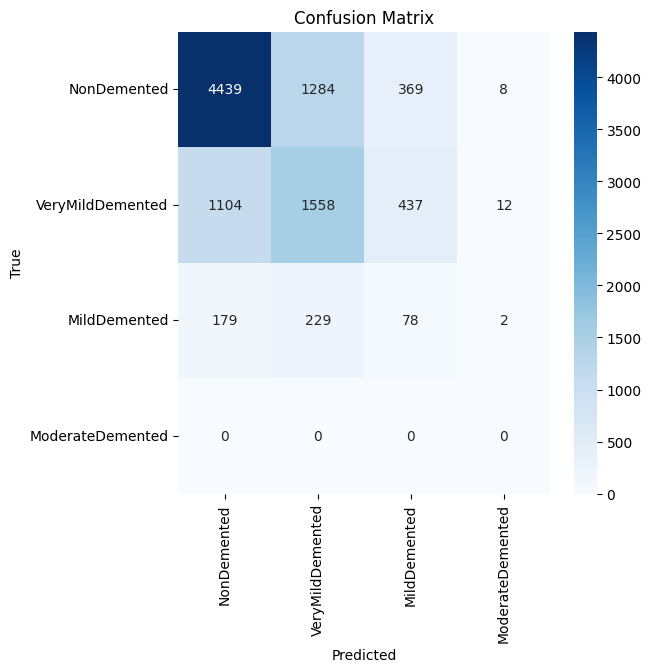

In [14]:
# ===============================
# FULL MODEL EVALUATION
# ===============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())


# ===============================
# METRICS
# ===============================

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

try:
    roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")
except:
    roc_auc = 0


print("\n==============================")
print("NeuroSight AI - Evaluation")
print("==============================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))


# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# ===============================
# ROC CURVE (Binary only)
# ===============================

if len(classes) == 2:

    probs_positive = np.array(all_probs)[:,1]

    fpr, tpr, _ = roc_curve(all_labels, probs_positive)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()


# ===============================
# PRECISION RECALL CURVE
# ===============================

if len(classes) == 2:

    precision_curve, recall_curve, _ = precision_recall_curve(all_labels, probs_positive)

    plt.figure()
    plt.plot(recall_curve, precision_curve)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()